In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import DataLoader
from datetime import datetime
import numpy as np
import pandas as pd

from utilities.data_processor import DataPreprocessor
from utilities.Task2_3b import (
    set_seed,
    TransformerModel,
    load_raw_to_grid,
    get_sparsity_mask,
    dataframe_to_triplets,
    PhysioNetDataset,
    collate_fn,
    clip_feature_values,
    run_training_pipeline,
    plot_training_results,
    run_final_test,
    report_test_results,
    clean_checkpoint_dir,
    STATIC_VARS,
    ALL_FEATURES
)

*Task 2.3b*

In [3]:
# Enforce reproducibility before any execution logic
SEED = 42
set_seed(SEED)

rnd_generator = torch.Generator()
rnd_generator.manual_seed(SEED)

In [4]:
# Initialization for model and hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
base_project_dir = "model_checkpoints/task_2_3b"
epochs = 2
CLIP = 5.0

model = TransformerModel(
    d_model=64,
    nhead=2,
    num_layers=3,
    d_time_emb=4,
    dim_feedforward=176,
    dropout=0.1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-5)

/Users/lorenzofrigoli/Documents/UZH/MSc/ML_for_HC/ML4HC_Project1/utilities/Task2_3b.py:266: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


In [5]:
raw_a, labels_a = load_raw_to_grid('ml4h_data/p1/set-a/', 'ml4h_data/p1/Outcomes-a.txt')
raw_b, labels_b = load_raw_to_grid('ml4h_data/p1/set-b/', 'ml4h_data/p1/Outcomes-b.txt')
raw_c, labels_c = load_raw_to_grid('ml4h_data/p1/set-c/', 'ml4h_data/p1/Outcomes-c.txt')

# RecordID -> PatientID
# Minutes  -> Timestamp
raw_a = raw_a.rename(columns={'RecordID': 'PatientID', 'Minutes': 'Timestamp'})
raw_b = raw_b.rename(columns={'RecordID': 'PatientID', 'Minutes': 'Timestamp'})
raw_c = raw_c.rename(columns={'RecordID': 'PatientID', 'Minutes': 'Timestamp'})

# Capture Sparsity Masks
mask_a = get_sparsity_mask(raw_a, STATIC_VARS)
mask_b = get_sparsity_mask(raw_b, STATIC_VARS)
mask_c = get_sparsity_mask(raw_c, STATIC_VARS)

# Fit and Transform using DataPreprocessor 
processor = DataPreprocessor(impute_outliers=True, impute_missing=True)
scaled_a = processor.fit_transform(raw_a)
scaled_b = processor.transform(raw_b)
scaled_c = processor.transform(raw_c)

# Restore Sparsity
scaled_a = scaled_a.where(mask_a)
scaled_b = scaled_b.where(mask_b)
scaled_c = scaled_c.where(mask_c)

# Clipping
scaled_a = clip_feature_values(scaled_a, ALL_FEATURES, min_val=-CLIP, max_val=CLIP)
scaled_b = clip_feature_values(scaled_b, ALL_FEATURES, min_val=-CLIP, max_val=CLIP)
scaled_c = clip_feature_values(scaled_c, ALL_FEATURES, min_val=-CLIP, max_val=CLIP)

Data clipped to range: [-5.0, 5.0] for 40 features.
Data clipped to range: [-5.0, 5.0] for 40 features.
Data clipped to range: [-5.0, 5.0] for 40 features.


In [6]:
# Create Loaders
train_triplets = dataframe_to_triplets(scaled_a, ALL_FEATURES)
train_loader = DataLoader(PhysioNetDataset(train_triplets, labels_a), 
                          batch_size=32, shuffle=True, collate_fn=collate_fn, generator=rnd_generator)

val_triplets = dataframe_to_triplets(scaled_b, ALL_FEATURES)
val_loader = DataLoader(PhysioNetDataset(val_triplets, labels_b), 
                        batch_size=32, shuffle=False, collate_fn=collate_fn, generator=rnd_generator)

test_triplets = dataframe_to_triplets(scaled_c, ALL_FEATURES)
test_loader = DataLoader(PhysioNetDataset(test_triplets, labels_c), 
                         batch_size=32, shuffle=False, collate_fn=collate_fn, generator=rnd_generator)

Converted DataFrame to 4000 patient sequences of triplets.
Converted DataFrame to 4000 patient sequences of triplets.
Converted DataFrame to 4000 patient sequences of triplets.


In [7]:
# Train the Model
training_results = run_training_pipeline(
    model=model,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    save_dir=base_project_dir,
    epochs=epochs
)

Epoch 01 | Train Loss: 0.4005 | Val Loss: 0.3935 | Val AuROC: 0.6623 | Val AuPRC: 0.2486
  >> Checkpoint synced to: model_checkpoints/task_2_3b/run_20260327_175247
  * Best model updated (AuPRC: 0.2486)
Epoch 02 | Train Loss: 0.3843 | Val Loss: 0.3840 | Val AuROC: 0.6961 | Val AuPRC: 0.2797
  >> Checkpoint synced to: model_checkpoints/task_2_3b/run_20260327_175247
  * Best model updated (AuPRC: 0.2797)


In [8]:
current_save_dir = training_results["save_dir"]
current_run_name = training_results["run_name"]

Cleaned plots saved to: model_checkpoints/task_2_3b/run_20260327_175247/training_curves.png


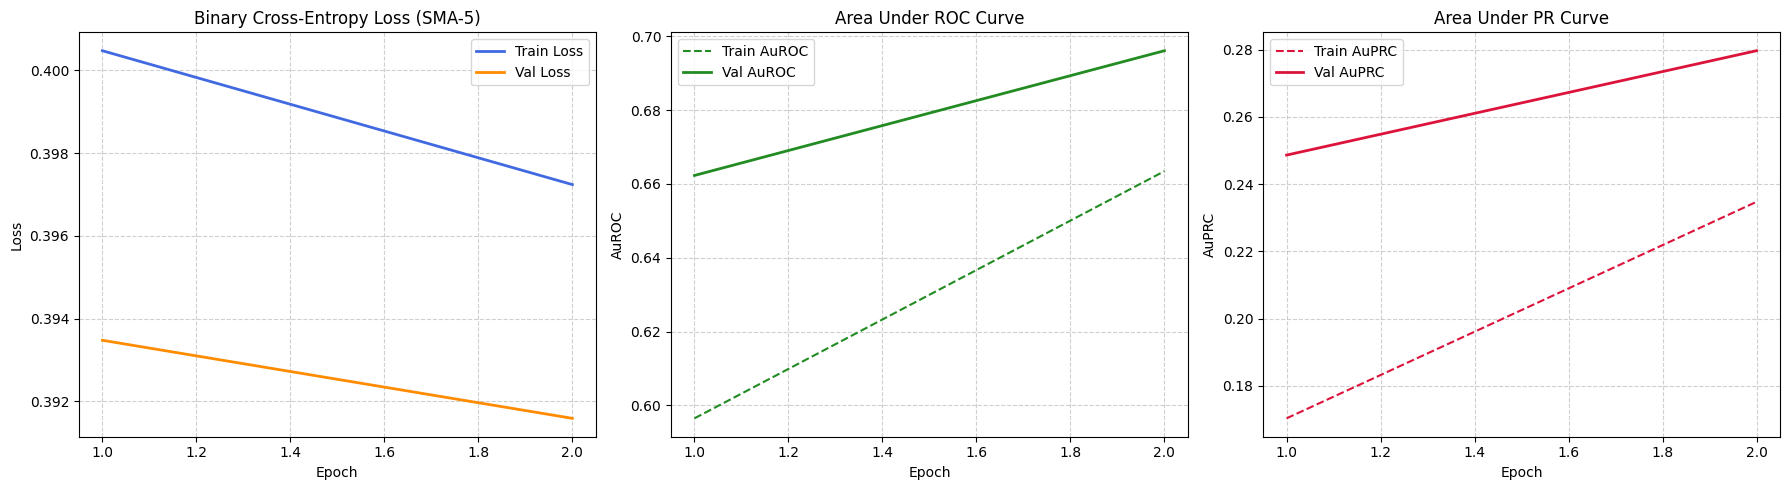

In [9]:
# Plot Metrics
plot_training_results(training_results["history"], save_path=current_save_dir / "training_curves.png")

In [10]:
# Test on the Test Set
best_model_path = current_save_dir / "best_model.pt"
test_results = run_final_test(
    model=model,
    test_loader=test_loader,
    checkpoint_path=str(best_model_path),
    device=device
)


Loading best model weights from: model_checkpoints/task_2_3b/run_20260327_175247/best_model.pt
Starting final evaluation on Set C...

FINAL TEST RESULTS (SET C)
AuROC: 0.6775
AuPRC: 0.2832
Loss:  0.3945


In [11]:
# Report the metric
report_test_results(test_results, model_name="Transformer (Task 2.3b)")


 FINAL PERFORMANCE REPORT: Transformer (Task 2.3b)
Metric          | Value     
----------------------------
AuROC           | 0.6775
AuPRC           | 0.2832
Test Loss       | 0.3945
---------------------------------------------
Transformer (Task 2.3b) & 0.6775 & 0.2832 & 0.3945 \\



In [12]:

# Clean checkpoint directory
clean_checkpoint_dir(base_dir="model_checkpoints/task_2_3b", keep_run_name=current_run_name)

Cleaning directory: model_checkpoints/task_2_3b
Keeping only: run_20260327_175247
  [Preserved] run_20260327_175247 (Best Model)
  [Deleted] run_20260327_174113

Cleanup complete. Removed 1 old run directories.
